In [1]:
import random
def generateData(x):
    data_x = []
    data_y = []
    for i in range(x):
        x1 = random.randint(-5,5)
        x2 = random.randint(-5,5)
        if (x1+x2 > 0):
            data_x.append([x1,x2])
            data_y.append(2)
        elif(x1+x2 < 0):
            data_x.append([x1,x2])
            data_y.append(0)
        else:
            data_x.append([x1,x2])
            data_y.append(1)
    return data_x,data_y



In [28]:
train_x,train_y = generateData(60)
test_x,test_y = generateData(60)

In [ ]:
train_x = [
    [0,0], [0,1], [1,0], [1,1]
]

train_y = [0,1,1,0]   # XOR pattern
from nn import MLP
from engine import Value
import random
model = MLP(2,[15,15,1])

beta_1 = 0.9
beta_2 = 0.999
lr = 0.1
eps = 1e-8

t = 1

data = list(zip(train_x,train_y))
batch_size = 2

m = [0 for _ in model.parameters()]
v = [0 for _ in model.parameters()]

for epoche in range(500):
    epoch_loss = 0
    random.shuffle(data)
    for batch_idx in range(0, len(data),batch_size):
        loss = Value(0)
        batch = data[batch_idx:batch_idx+batch_size]
        for x, y in batch:
            prob = model(x)[0]
            # y*log(p)
            term1 = y*prob.log()
            term2 = (1-y)*((1-prob)+ 0.0000001).log()
            loss -= term1 + term2
            
        reg_loss = Value(0)
        # L2 Regularization
        for p in model.parameters():
            reg_loss += p*p
        loss = loss + 0.01 * reg_loss
        loss.backward()

        # Momentum
        for i,p in enumerate(model.parameters()):
            # Momentum
            m[i] = beta_1*m[i] + (1-beta_1) * p.grad
            # Scaling
            v[i] = beta_2*v[i] + (1-beta_2) * (p.grad ** 2)
            # Bias Correction 
            
            m_hat = m[i] / (1 - beta_1**t)
            v_hat = v[i] / (1 - beta_2**t)

            # Update
            p.data += -lr*m_hat/(v_hat**0.5 + eps)
            p.grad = 0
        epoch_loss += loss
        t += 1
    print((epoch_loss * (1 / len(data))).data)

1.460336839982915
0.8980533826529095
1.098230866673799
0.9491455488313149
0.7329405569115189
0.6402790438720958
0.5390687844869632
0.5067441277924857
0.44671896911074765
0.4156055824649245
0.3864478106724113
0.35725657936385335
0.33835048435425435
0.32643687481774003
0.31751147565274473
0.30570401329596397
0.2931629954521242
0.2810448476683307
0.2687623227127035
0.2571787893095244
0.24811328197828336
0.23861505065410368
0.23070308992000493
0.2248023562848615
0.21725961911362418
0.21419003580496304
0.20727030104521366
0.20336153639270305
0.20066893659067694
0.19595255851535004
0.19450036989925656
0.1936152224380393
0.19034847442855804
0.1873980022217231
0.18492669116051053
0.18317976024552265
0.1817160493870924
0.1798318062125966
0.1797788647126417
0.17778916575390552
0.1765490424617916
0.17871314688295675
0.1754526157943554
0.17524711600306508
0.1754570674118443
0.17314956220345956
0.17481345567548184
0.17196809826594595
0.17316896905907553
0.17126835899575896
0.17171911985238542
0.171

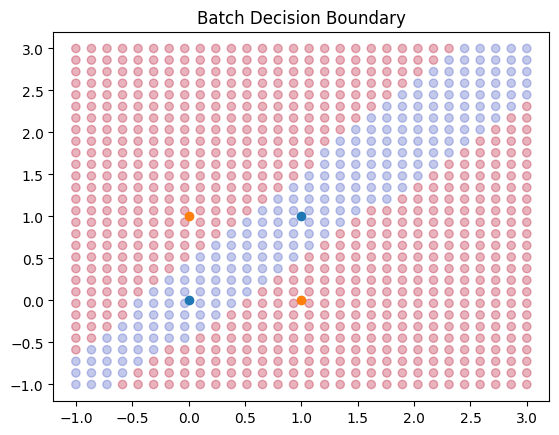

In [31]:
import numpy as np
grid = []
for x in np.linspace(-1,3,30):
    for y in np.linspace(-1,3,30):
        grid.append([x,y])
def predict(x):
    pred = model(x)[0].data
    return (1 if(pred>0.5) else 0)
pred = []
for point in grid:
    _pred = predict(point)
    pred.append(_pred)
import matplotlib.pyplot as plt

xs0 = [x[0] for x, y in zip(train_x, train_y) if y == 0]
ys0 = [x[1] for x, y in zip(train_x, train_y) if y == 0]

xs1 = [x[0] for x, y in zip(train_x, train_y) if y == 1]
ys1 = [x[1] for x, y in zip(train_x, train_y) if y == 1]

xs = [p[0] for p in grid]
ys = [p[1] for p in grid]

plt.scatter(xs, ys, c=pred, cmap='coolwarm', alpha=0.3)
plt.scatter(xs0, ys0)
plt.scatter(xs1, ys1)

plt.title("Batch Decision Boundary")
plt.show()

In [32]:
import random
temp = [[a,b] for a,b in zip(train_x,train_y)]
random.shuffle(temp)
print(temp)
train_x, train_y = map(list, zip(*temp))

[[[1, 0], 1], [[0, 1], 1], [[0, 0], 0], [[1, 1], 0]]


In [33]:
for x, y in zip(train_x,train_y):
        logits = model(x)[0]
        print(f'pred:{1 if(logits.data>0.5)else 0}, original:{y}')

pred:1, original:1
pred:1, original:1
pred:0, original:0
pred:0, original:0


####  MNIST

In [2]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

mnist = fetch_openml('mnist_784',version=1)

X = mnist.data.astype(float).to_numpy() /255.0
y = mnist.target.astype(int).to_numpy()
X = X[:50]
y = y[:50]
# print(f'Shape of X:{X.shape}\nShape of y:{y}')

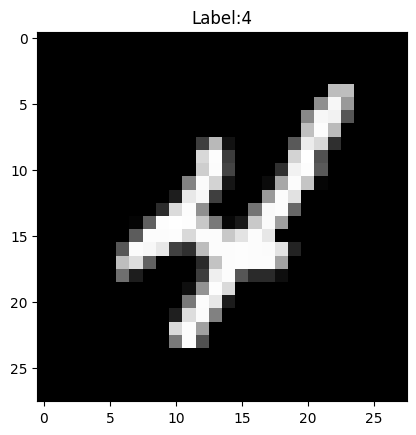

In [3]:
plt.imshow(X[9].reshape(28,28),cmap='gray')
plt.title(f"Label:{y[9]}")
plt.show()

In [4]:
def cross_entropy_logits(logits, y_true):
    max_logit = max(x.data for x in logits)
    exps = [(x-max_logit).exp() for x in logits]
    sum_exp = exps[0]
    for s in exps[1:]:
        sum_exp += s
    log_sum_exp = sum_exp.log() + max_logit

    return (log_sum_exp - logits[y_true])


In [5]:
from nn import MLP
from engine import Value
import random
model = MLP(784,[32,10])
batch_size = 16
lr = 0.001

m = [0 for _ in model.parameters()]
v = [0 for _ in model.parameters()]
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

t = 1
data = list(zip(X,y))
for epoch in range(3):
    random.shuffle(data)
    total_loss = 0
    for batch_idx in range(0,len(data),batch_size):
        batch = data[batch_idx:batch_idx+batch_size]
        loss = Value(0)
        for x,y_true in batch:
            logits = model(x)
            
            loss += cross_entropy_logits(logits,y_true)
        loss.backward()
        for j, p in enumerate(model.parameters()):
            m[j] = beta1*m[j] + (1-beta1) * p.grad
            v[j] = beta2*v[j] + (1-beta2) * (p.grad**2)

            m_hat = m[j]/(1-beta1**t)
            v_hat = v[j]/(1-beta2**t)
            p.data += -lr * m_hat / (v_hat**0.5 + eps)
            p.grad = 0
        total_loss += loss.data
        t += 1
    print(f"Epoch {epoch}, Loss:{total_loss/len(data)}")


Epoch 0, Loss:2.321109306388503
Epoch 1, Loss:2.281742083991217
Epoch 2, Loss:2.2492218278410725


In [ ]:
## for tensor engine based training check outvector_based_mnist_model.ipynb